   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  

Dataset Shape: (45211, 17)

Columns: Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housi

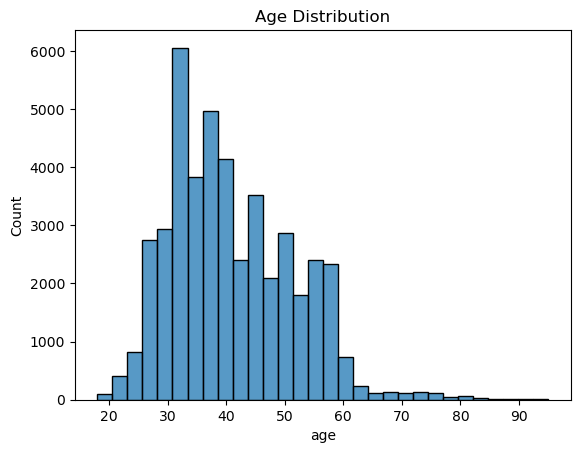

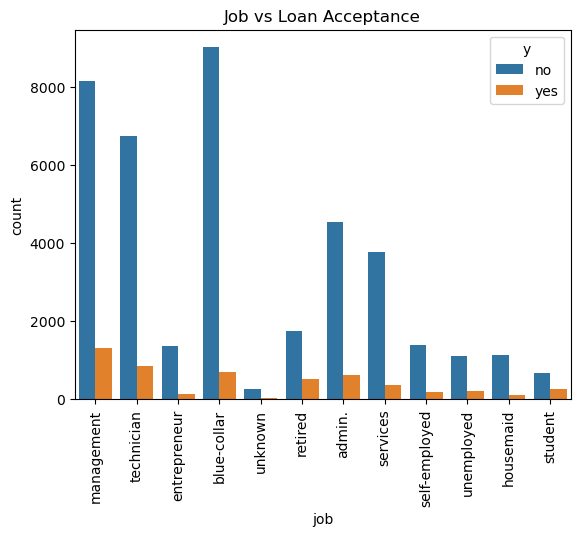

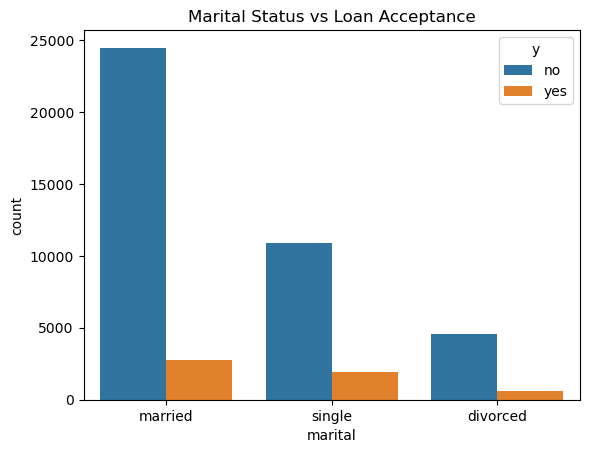

C:\Users\faraz\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model Accuracy: 0.8979321021784806


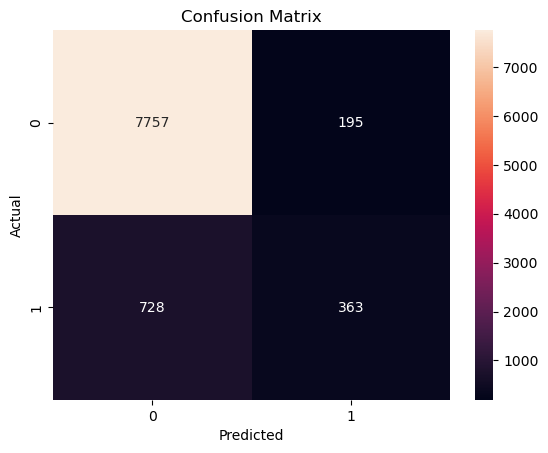

In [2]:
# Task 5: Personal Loan Acceptance Prediction
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Load Dataset
data = pd.read_csv("bank-full.csv", sep=';')   # dataset uses ; as separator

# Display first rows
print(data.head())

# Basic Data Exploration
print("\nDataset Shape:", data.shape)
print("\nColumns:", data.columns)

print("\nDataset Info:")
print(data.info())

print("\nSummary Statistics:")
print(data.describe())

# Data Visualization
# Age distribution
plt.figure()
sns.histplot(data['age'], bins=30)
plt.title("Age Distribution")
plt.show()

# Job vs Loan Acceptance
plt.figure()
sns.countplot(x='job', hue='y', data=data)
plt.xticks(rotation=90)
plt.title("Job vs Loan Acceptance")
plt.show()

# Marital Status vs Loan Acceptance
plt.figure()
sns.countplot(x='marital', hue='y', data=data)
plt.title("Marital Status vs Loan Acceptance")
plt.show()

# Encode Categorical Variables
data = pd.get_dummies(data, drop_first=True)

# Feature Selection
X = data.drop('y_yes', axis=1)   # target variable
y = data['y_yes']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()